# Assignment 1
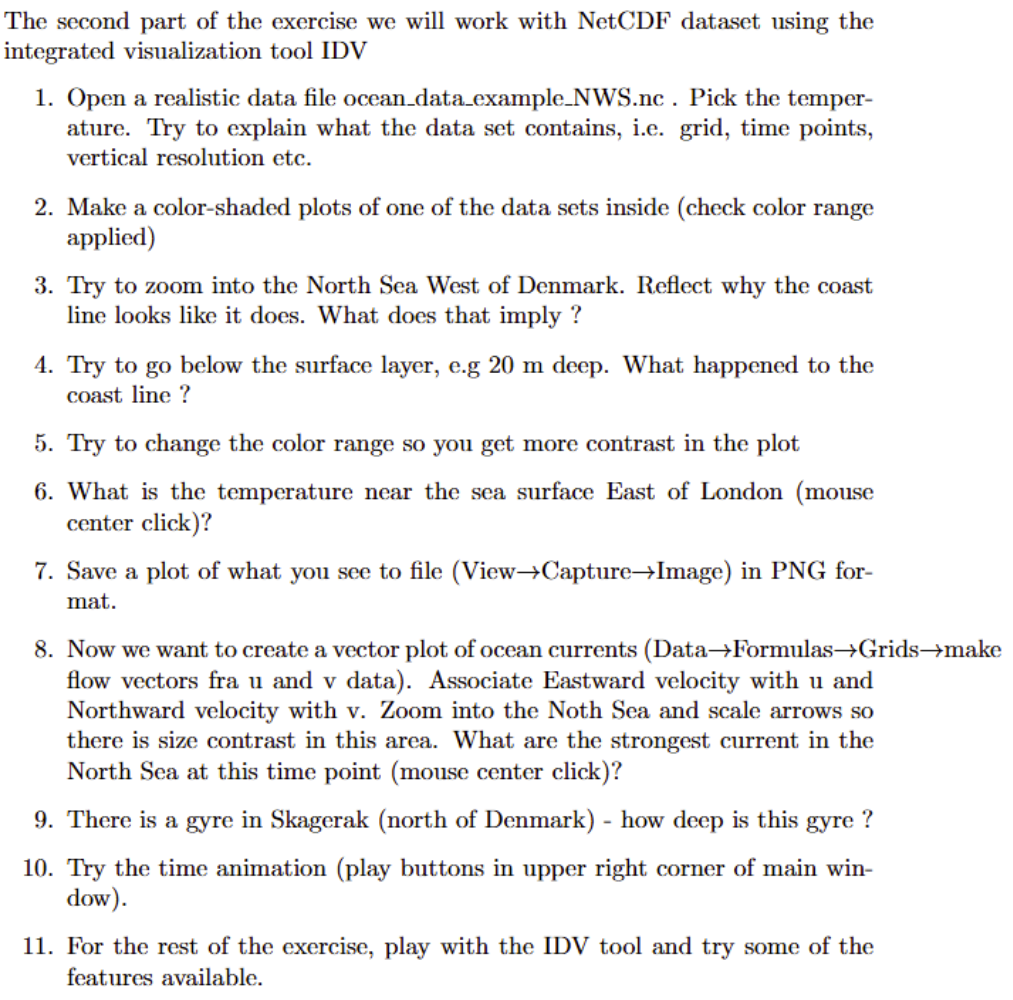

In [1]:
# Import libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4 as netcdf

In [2]:
# Load the dataset
data = "C:/Users/natal/OneDrive - Danmarks Tekniske Universitet/25340 Digital Ocean/ocean_data_example_NWS.nc"

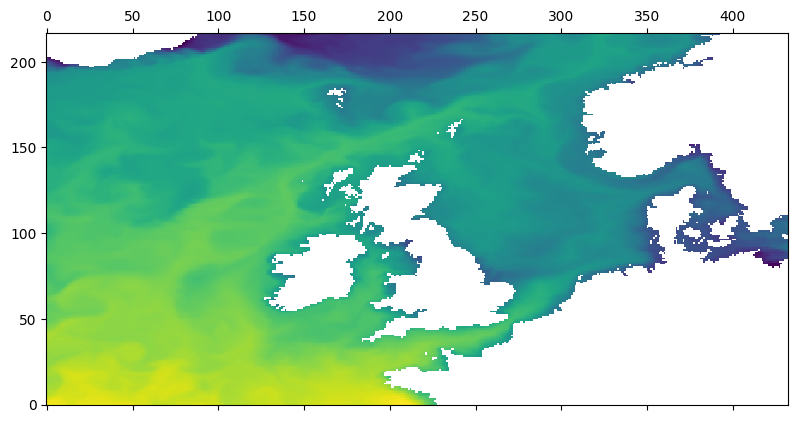

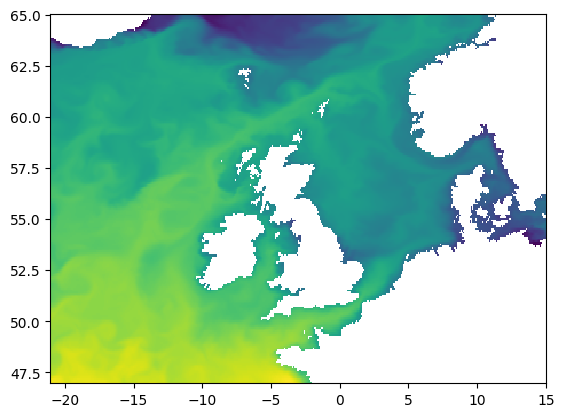

[ 0.494025  1.541375  2.645669  3.819495  5.078224  6.440614  7.92956
  9.572997 11.405    13.46714  15.81007  18.49556  21.59882  25.21141
 29.44473  34.43415  40.34405  47.37369 ]
[7.410962261259556 7.410962261259556 7.411694705486298 7.411694705486298
 7.412427149713039 7.412427149713039 7.412427149713039 7.412427149713039
 7.412427149713039 7.412427149713039 7.412427149713039 7.413159593939781
 7.413159593939781 7.413159593939781 7.412427149713039 7.413159593939781
 -- --]


In [3]:
nc = netcdf.Dataset(data, "r")
tempdata = nc.variables["thetao"][:] # (time, depth, latitude, longitude)
tempdata.shape # print data layout

# ----- Raw plot -----
plt.matshow(tempdata[0,0], origin='lower')
plt.show() # render plot

# ----- With longitude/latitude axes -----
lon = nc.variables["longitude"]
lat = nc.variables["latitude"]
X,Y = np.meshgrid(lon,lat)
plt.pcolormesh(X, Y, tempdata[0,0], shading='nearest')
plt.show()

# ----- Access data vector 301,101 - first time frame
depth = nc.variables["depth"][:]
print(depth)
print(tempdata[0,:,100,300])

### Exercise 1

In [4]:
# Display dataset information
'''print("Dataset Info:")
print(nc)
print("\n" + "="*50 + "\n")
'''
print("Variables in the dataset:")
for var in nc.variables:
    print(f"  {var}: {nc.variables[var].dimensions}, shape: {nc.variables[var].shape}")


Variables in the dataset:
  depth: ('depth',), shape: (18,)
  latitude: ('latitude',), shape: (217,)
  longitude: ('longitude',), shape: (433,)
  time: ('time',), shape: (12,)
  thetao: ('time', 'depth', 'latitude', 'longitude'), shape: (12, 18, 217, 433)
  uo: ('time', 'depth', 'latitude', 'longitude'), shape: (12, 18, 217, 433)
  vo: ('time', 'depth', 'latitude', 'longitude'), shape: (12, 18, 217, 433)


### Exercise 2

Data min: 2.40
Data max: 13.16



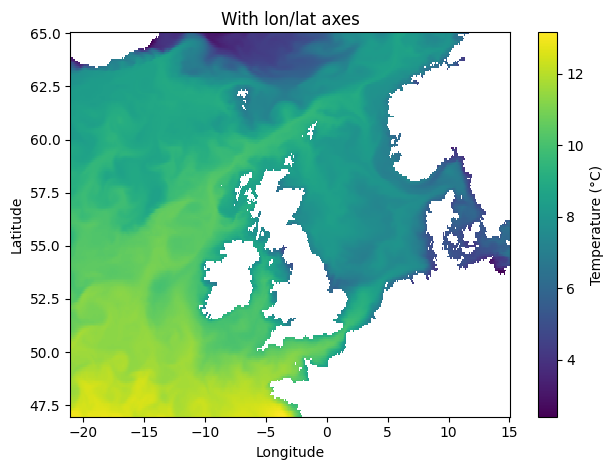

Color range: (2.401043750345707, 13.164311662316322)


In [5]:
# Check color range and add colorbars
print(f"Data min: {np.nanmin(tempdata[0,0]):.2f}")
print(f"Data max: {np.nanmax(tempdata[0,0]):.2f}")
print()

# With lon/lat axes and colorbar
im2 = plt.pcolormesh(X, Y, tempdata[0,0], shading='nearest')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('With lon/lat axes')
cbar = plt.colorbar(im2)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()

# To get the color limits from a plot:
print(f"Color range: {im2.get_clim()}")

### Exercise 3
There course coast line is due to the grid resolution. Each cell is identified either as the ocean or the land. Nothing in between therefore that is why there is such a harsh change in the coastline. 

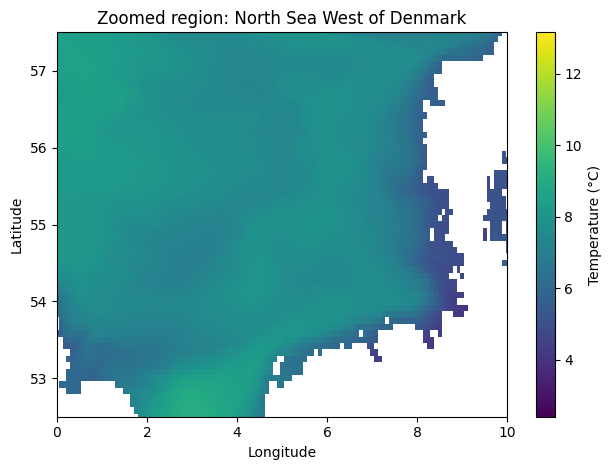

In [6]:
# With lon/lat axes and colorbar - zoomed to specific region
im2 = plt.pcolormesh(X, Y, tempdata[0,0], shading='nearest')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Zoomed region: North Sea West of Denmark')
plt.xlim(0, 10)  # Longitude range
plt.ylim(52.5, 57.5)  # Latitude range
cbar = plt.colorbar(im2)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()


### Exercise 4
There coastline has changed as more of the grids have now been identified as the land and not as the ocean.

In [7]:
print("Available depths (meters):")
for i, d in enumerate(depth):
    print(f"  Index {i}: {d:.2f} m")

Available depths (meters):
  Index 0: 0.49 m
  Index 1: 1.54 m
  Index 2: 2.65 m
  Index 3: 3.82 m
  Index 4: 5.08 m
  Index 5: 6.44 m
  Index 6: 7.93 m
  Index 7: 9.57 m
  Index 8: 11.40 m
  Index 9: 13.47 m
  Index 10: 15.81 m
  Index 11: 18.50 m
  Index 12: 21.60 m
  Index 13: 25.21 m
  Index 14: 29.44 m
  Index 15: 34.43 m
  Index 16: 40.34 m
  Index 17: 47.37 m


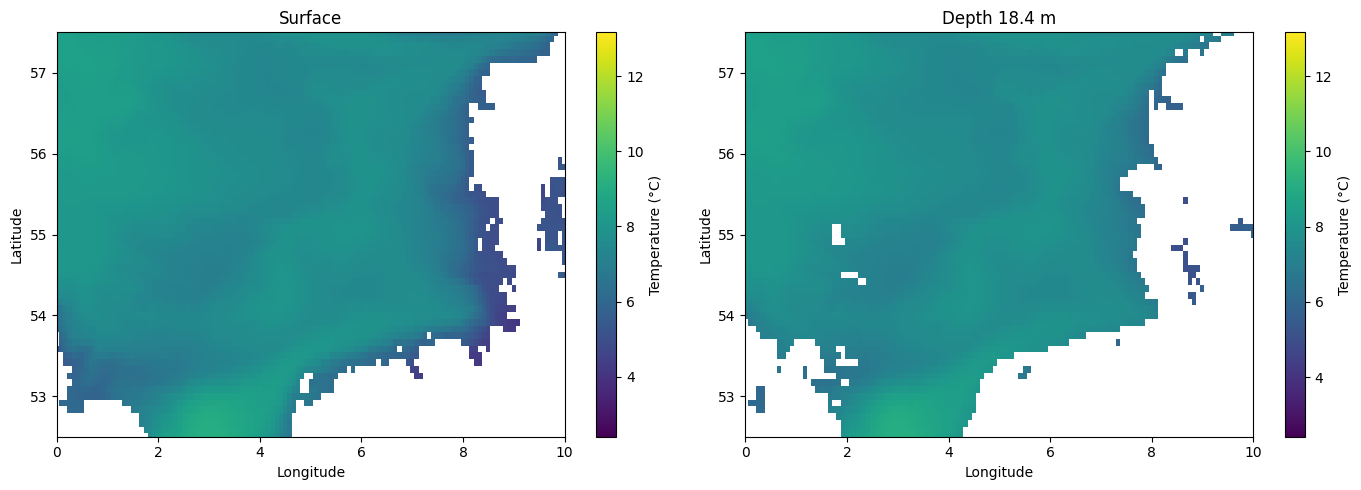

In [19]:
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# First plot - surface (depth index 0)
im1 = ax1.pcolormesh(X, Y, tempdata[0,0], shading='nearest')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Surface')
ax1.set_xlim(0, 10)
ax1.set_ylim(52.5, 57.5)
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Temperature (°C)')

# Second plot - depth index 11
im2 = ax2.pcolormesh(X, Y, tempdata[0,11], shading='nearest')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Depth ' + depth[11].astype(str)[:4] + ' m')
ax2.set_xlim(0, 10)
ax2.set_ylim(52.5, 57.5)
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()


### Exercise 5

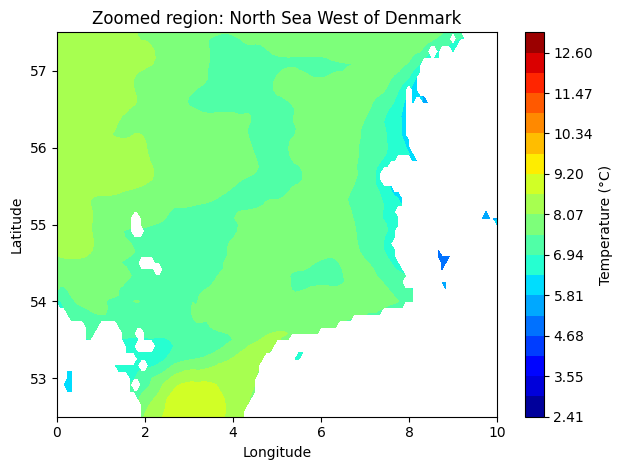

In [31]:
# With lon/lat axes and colorbar - zoomed to specific region with adjusted temp range legend
# Use contourf with more levels for smoother color gradients
levels = np.linspace(np.nanmin(tempdata[0,11]), np.nanmax(tempdata[0,11]), 20)
im2 = plt.contourf(X, Y, tempdata[0,11], levels=levels, cmap='jet')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Zoomed region: North Sea West of Denmark')
plt.xlim(0, 10)  # Longitude range
plt.ylim(52.5, 57.5)  # Latitude range
cbar = plt.colorbar(im2)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()


### Exercise 6